In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 


In [2]:
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv',
                parse_dates=[1], 
                index_col= 'id')



/tmp/ipykernel_444324/2532432345.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv',


In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  object 
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  updated    120108 non-null  object 
 12  place      120108 non-null  object 
 13  type       120108 non-null  object 
dtypes: float64(7), object(7)
memory usage: 13.7+ MB


In [4]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.251999999999995,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.0703,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.6717,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.1887,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833299999996,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [5]:
df.describe()

,longitude,depth,mag,nst,gap,dmin,rms
count,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
std,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046
min,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000


In [6]:
df['country'] = df['place'].str.rsplit(',' , n=1).str[1]

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.251999999999995,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake,Alaska
nn00436847,2014-01-31 23:48:35.452,37.0703,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake,Nevada
ak11151142,2014-01-31 23:47:24.000,64.6717,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake,Alaska
ak11151135,2014-01-31 23:30:54.000,63.1887,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake,Alaska
ci37171541,2014-01-31 23:30:52.210,32.616833299999996,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake,Mexico


In [7]:
top_20 = df.nlargest(20, 'mag')
top_20


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usc000nzvd,2014-04-01 23:46:47.260,-19.6097,-70.7691,25.00,8.2,mww,NaN,23.0,0.609,0.66,us,2015-07-30T16:24:51.223Z,"94km NW of Iquique, Chile",earthquake,Chile
usc000rki5,2014-06-23 20:53:09.700,51.8486,178.7352,109.00,7.9,mww,NaN,22.0,0.133,0.71,us,2015-04-18T21:54:08.699Z,"19km SE of Little Sitkin Island, Alaska",earthquake,Alaska
usc000p27i,2014-04-03 02:43:13.110,-20.5709,-70.4931,22.40,7.7,mww,NaN,44.0,1.029,0.82,us,2015-06-06T07:31:05.755Z,"53km SW of Iquique, Chile",earthquake,Chile
usc000phx5,2014-04-12 20:14:39.300,-11.2701,162.1481,22.56,7.6,mww,NaN,13.0,2.828,0.71,us,2015-04-18T21:54:27.398Z,"93km SSE of Kirakira, Solomon Islands",earthquake,Solomon Islands
usb000pr89,2014-04-19 13:28:00.810,-6.7547,155.0241,43.37,7.5,mww,NaN,16.0,3.820,1.25,us,2015-04-18T21:54:18.633Z,"70km SW of Panguna, Papua New Guinea",earthquake,Papua New Guinea
usc000piqj,2014-04-13 12:36:19.230,-11.4633,162.0511,39.00,7.4,mww,NaN,17.0,2.885,1.00,us,2015-08-13T19:29:13.018Z,"112km S of Kirakira, Solomon Islands",earthquake,Solomon Islands
usb000slwn,2014-10-14 03:51:34.460,12.5262,-88.1225,40.00,7.3,mww,NaN,18.0,1.078,0.70,us,2015-08-13T19:35:02.679Z,"74km S of Intipuca, El Salvador",earthquake,El Salvador
usb000pq41,2014-04-18 14:27:24.920,17.397000000000002,-100.9723,24.00,7.2,mww,NaN,46.0,2.250,1.20,us,2015-08-13T19:30:39.599Z,"33km ESE of Petatlan, Mexico",earthquake,Mexico
usc000pft9,2014-04-11 07:07:23.130,-6.5858,155.0485,60.53,7.1,mww,NaN,21.0,3.729,0.88,us,2014-07-01T02:37:56.000Z,"56km WSW of Panguna, Papua New Guinea",earthquake,Papua New Guinea


In [8]:
top_20['country'].unique()

array([' Chile', ' Alaska', ' Solomon Islands', ' Papua New Guinea',
       ' El Salvador', ' Mexico', ' Indonesia', ' Fiji', nan, ' China',
       ' Greece', ' ', ' New Zealand'], dtype=object)

In [9]:
mag_over4 = df[df['mag'] >= 4]

mag_over4.head()


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usc000mqlp,2014-01-31 23:08:03.660,-4.9758,153.9466,110.18,4.2,mb,NaN,98.0,1.940,0.61,us,2014-04-08T01:43:19.000Z,"115km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea
usc000mqln,2014-01-31 22:54:32.970,-28.1775,-177.9058,95.84,4.3,mb,NaN,104.0,1.063,1.14,us,2014-04-08T01:43:19.000Z,"120km N of Raoul Island, New Zealand",earthquake,New Zealand
usc000mqls,2014-01-31 22:49:49.740,-23.1192,179.1174,528.34,4.4,mb,NaN,80.0,5.439,0.95,us,2014-04-08T01:43:19.000Z,South of the Fiji Islands,earthquake,NaN
usc000mf1x,2014-01-31 22:19:44.330,51.1569,-178.0910,37.50,4.2,mb,NaN,NaN,NaN,0.83,us,2014-04-08T01:43:19.000Z,"72km E of Amatignak Island, Alaska",earthquake,Alaska
usc000mqlm,2014-01-31 21:56:44.320,-4.88,153.8434,112.66,4.3,mb,NaN,199.0,1.808,0.79,us,2014-04-08T01:43:19.000Z,"100km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea


In [10]:
frequencies = mag_over4['country'].value_counts()
top_5 = frequencies[0:5]



Text(0, 0.5, 'Count (log scale)')

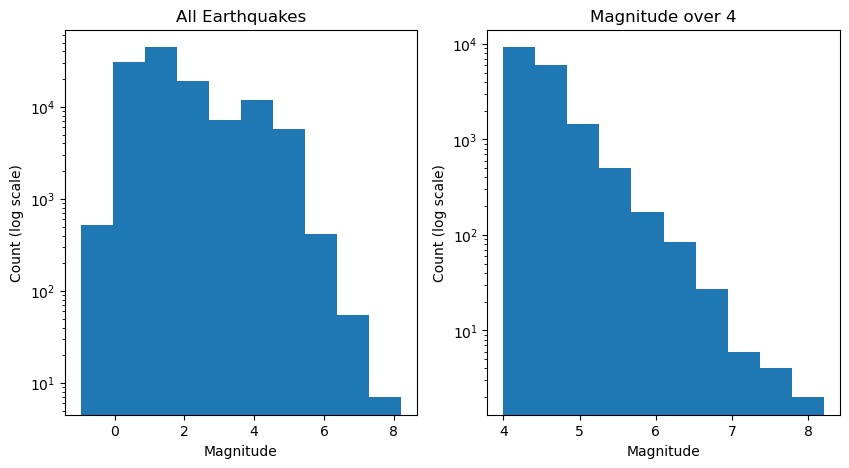

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].hist(x=df['mag'], log=True)
axes[0].set_title("All Earthquakes")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Count (log scale)")


axes[1].hist(x=mag_over4['mag'], log=True)
axes[1].set_title("Magnitude over 4")
axes[1].set_xlabel("Magnitude")
axes[1].set_ylabel("Count (log scale)")

On the histogram with only earthquakes with a magnitude over 4, there is a step-like relationship as magnitude grows. As magnitude increases, the frequency of earthquakes decreases exponentially. The unfiltered plot is dominated by the large number of small earthquakes. The filtered plot makes the distribution of larger earthquakes easier to see and interpret.

In [12]:
df.shape
print(df["latitude"].describe())
print(df["longitude"].describe())

df['latitude'] = df['latitude'].astype('float64')
mag_over4['latitude'] = mag_over4['latitude'].astype('float64')

count      120108
unique      77825
top       38.8235
freq           50
Name: latitude, dtype: object
count    120108.000000
mean        -99.961402
std          82.996858
min        -179.998900
25%        -147.742025
50%        -120.832000
75%        -116.068100
max         179.998000
Name: longitude, dtype: float64


/tmp/ipykernel_444324/2170133372.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mag_over4['latitude'] = mag_over4['latitude'].astype('float64')


In [13]:
mag_over4.shape

(17547, 15)

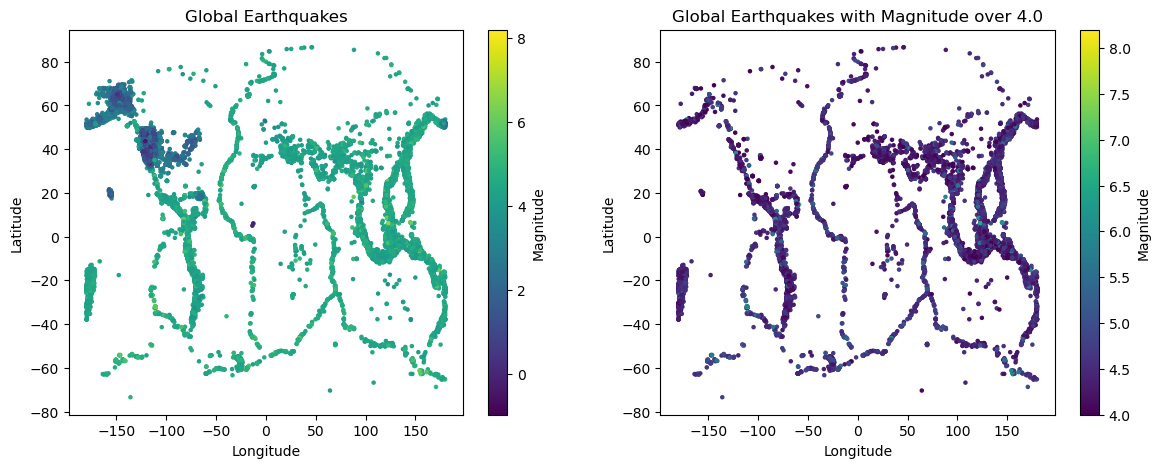

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df1 = axes[0].scatter(x=df["longitude"], y=df["latitude"],
                c=df['mag'], cmap="viridis", s=5)
axes[0].set_title("Global Earthquakes")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

plt.colorbar(df1, ax=axes[0], label='Magnitude')

df2 = axes[1].scatter(x=mag_over4["longitude"], y=mag_over4["latitude"],
                c=mag_over4['mag'], cmap="viridis", s=5)
axes[1].set_title("Global Earthquakes with Magnitude over 4.0")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")


plt.colorbar(df2, ax=axes[1], label='Magnitude')

It is easier to note the higher magnitude earthquakes on the filtered plot. It becomes easier to see where the light colors/outliers are because the majoirty of the points are concentrated in the bottom range. Comparatively, the unfiltered chart is harder to read and dicipher the higher magnitude earthquakes. The earthquakes are also concentrated in the same areas in both graphs, likely aligning with the tectonic plates. Even when filtering to only magnitude over 4, the earthquakes are concentrated in the same areas, suggesting that the largest earthquakes occur along the same fault lines as smaller ones.